### Imports

In [1]:
import pandas as pd
import numpy as np
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

### Load Dataset

In [2]:
def load_and_clean_data(path):
    df = pd.read_csv("C:\\Users\\katta\\Downloads\\data (1).csv")
    df.dropna(inplace=True)
    return df

### Feature Engineering

In [3]:
def create_features(df):
    expense_columns = [
        "Rent", "Loan_Repayment", "Insurance", "Groceries", "Transport",
        "Eating_Out", "Entertainment", "Utilities",
        "Healthcare", "Education", "Miscellaneous"
    ]

    df["Total_Expenses"] = df[expense_columns].sum(axis=1)
    df["expense_ratio"] = df["Total_Expenses"] / df["Income"]
    df["savings_ratio"] = df["Desired_Savings"] / df["Income"]

    return df

In [4]:
DATA_PATH = "../data/financial_data.csv"

df = load_and_clean_data(DATA_PATH)
df = create_features(df)

df.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,...,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous,Total_Expenses,expense_ratio,savings_ratio
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,...,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517,33371.621929,0.747618,0.138909
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,...,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606,17181.777859,0.639712,0.071604
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,...,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422,36476.154459,0.724199,0.139978
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,...,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183,69837.646632,0.688357,0.164554
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,...,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076,18609.583016,0.748115,0.075340


### Prepare Training

In [5]:
features = [
    "Income", "Age", "Dependents",
    "expense_ratio", "savings_ratio", "Disposable_Income"
]

X = df[features]
y = df["Desired_Savings"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### train Regression

In [6]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

### Evaluate Model

In [7]:
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.9319924688136226
MAE: 118.40847045932017


### Save Model

In [8]:
os.makedirs("../outputs/models", exist_ok=True)

joblib.dump(model, "../outputs/models/savings_prediction_model.pkl")

print("✅ Regression model saved successfully")

✅ Regression model saved successfully


### We trained a Random Forest regression model to predict desired savings using income, expense ratios, and demographic features. The model captures non-linear spending behavior effectively.

In [9]:
import pandas as pd
import os

os.makedirs("../outputs", exist_ok=True)

pd.DataFrame(y_test).to_csv("../outputs/y_test.csv", index=False)
pd.DataFrame(y_pred).to_csv("../outputs/y_pred.csv", index=False)

print("✅ y_test.csv and y_pred.csv saved successfully")

✅ y_test.csv and y_pred.csv saved successfully


In [10]:
import pandas as pd

results = pd.DataFrame({
    'Actual': y_test[:10],
    'Predicted': y_pred[:10]
})

print(results)

            Actual    Predicted
10650  1577.914091  1603.650977
2041   1972.333691  1951.374385
8668   4169.770337  4261.108360
1114   2802.129842  2833.452677
13902  2806.258857  2770.442890
11963  1202.874008  1213.821064
11072   802.312923   813.791846
3002   1412.579268  1436.148146
19771  1036.860511  1019.821544
8115   1584.228375  1552.904036


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/figures/.png.png'

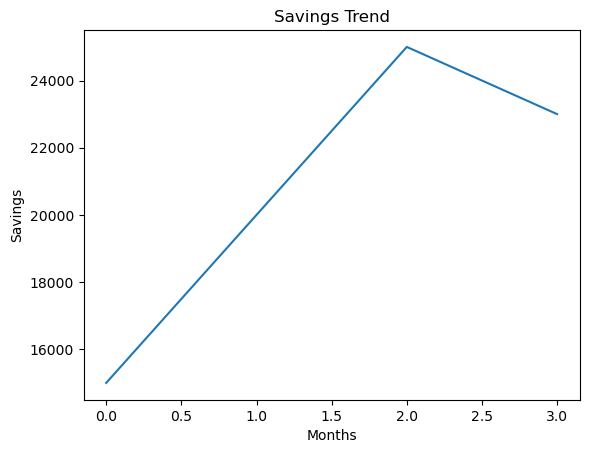

In [11]:
savings = [15000, 20000, 25000, 23000]

plt.plot(savings)

plt.title("Savings Trend")
plt.xlabel("Months")
plt.ylabel("Savings")
plt.savefig(
    "outputs/figures/.png",
    dpi=300,
    bbox_inches="tight"

)

plt.show()

NameError: name 'Output' is not defined

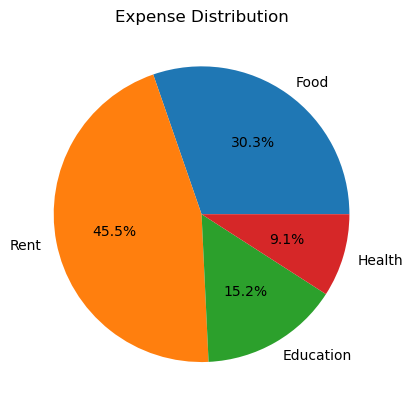

In [ ]:
labels = ['Food', 'Rent', 'Education', 'Health']
values = [10000, 15000, 5000, 3000]

plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title("Expense Distribution")
plt.savefig(
    Output/figures/Expense_Distribution.png,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

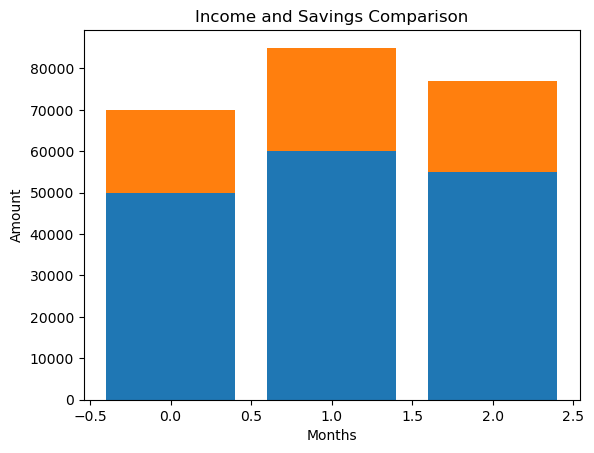

In [ ]:
income = [50000, 60000, 55000]
savings = [20000, 25000, 22000]

x = range(len(income))

plt.bar(x, income)
plt.bar(x, savings, bottom=income)

plt.title("Income and Savings Comparison")
plt.xlabel("Months")
plt.ylabel("Amount")
plt.show()

In [ ]:
df['total_savings'] = df['Potential_Savings_Education'] + df['Potential_Savings_Healthcare']

print(df)

              Income  Age  Dependents     Occupation City_Tier          Rent  \
0       44637.249636   49           0  Self_Employed    Tier_1  13391.174891   
1       26858.596592   34           2        Retired    Tier_2   5371.719318   
2       50367.605084   35           1        Student    Tier_3   7555.140763   
3      101455.600247   21           0  Self_Employed    Tier_3  15218.340037   
4       24875.283548   52           4   Professional    Tier_2   4975.056710   
...              ...  ...         ...            ...       ...           ...   
19995   40913.466178   51           4  Self_Employed    Tier_1  12274.039853   
19996   90295.772638   21           1        Student    Tier_2  18059.154528   
19997   40604.567373   30           1   Professional    Tier_2   8120.913475   
19998  118157.817240   27           2   Professional    Tier_1  35447.345172   
19999    8209.249769   62           3   Professional    Tier_1   2462.774931   

       Loan_Repayment    Insurance     

In [ ]:
from sklearn.linear_model import LinearRegression

X = df[['Income', 'Total_Expenses']]
y = df['total_savings']

model = LinearRegression()
model.fit(X, y)

prediction = model.predict([[70000, 40000]])

print("Predicted Savings:", prediction)

Predicted Savings: [146.46613024]


C:\Users\katta\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
